# Social Proximity Onset vs Syllables and Transitions

This notebook tests whether social proximity onsets are associated with specific active syllables or specific syllable transitions. It mirrors the logic in `social_proximity_transition_analysis.py`, but keeps each analysis stage editable and inspectable.

In [111]:
from __future__ import annotations

from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import binomtest, ttest_ind

In [112]:
PROJECT_ROOT = Path.cwd()
if PROJECT_ROOT.name in {"Pose_Tracking", "Keypoint_moseq_analysis"}:
    ROOT = PROJECT_ROOT.parent
else:
    ROOT = PROJECT_ROOT

POSE_DIR = ROOT / "Pose_Tracking"
KPMS_DIR = ROOT / "Keypoint_moseq_analysis"
ALIGNMENT_DIR = KPMS_DIR / "Pose_Tracking" / "syllable_transition_da_alignment_outputs"

DA_PATH = POSE_DIR / "home_cage_pose_DA_all.csv"
RUNS_PATH = ALIGNMENT_DIR / "subject_syllable_runs.csv"
TRANSITIONS_PATH = ALIGNMENT_DIR / "subject_syllable_transitions.csv"

TIME_TOLERANCE_S = 0.11
TRANSITION_MATCH_TOLERANCE_S = 0.15
MIN_COUNT_FOR_REPORT = 3

print(f"DA_PATH: {DA_PATH}")
print(f"RUNS_PATH: {RUNS_PATH}")
print(f"TRANSITIONS_PATH: {TRANSITIONS_PATH}")

sns.set_style("whitegrid")
pd.set_option("display.max_columns", 200)

DA_PATH: c:\Users\alber\OneDrive\Documents\GitHub\Fiber_Photometry_revisions\Pose_Tracking\home_cage_pose_DA_all.csv
RUNS_PATH: c:\Users\alber\OneDrive\Documents\GitHub\Fiber_Photometry_revisions\Keypoint_moseq_analysis\Pose_Tracking\syllable_transition_da_alignment_outputs\subject_syllable_runs.csv
TRANSITIONS_PATH: c:\Users\alber\OneDrive\Documents\GitHub\Fiber_Photometry_revisions\Keypoint_moseq_analysis\Pose_Tracking\syllable_transition_da_alignment_outputs\subject_syllable_transitions.csv


## Helper functions

In [113]:
def _clean_string(series: pd.Series) -> pd.Series:
    return series.astype(str).str.strip()


def _bool_from_yes(series: pd.Series) -> pd.Series:
    return _clean_string(series).str.lower().eq("yes")


def _bool_from_mixed(series: pd.Series) -> pd.Series:
    lowered = _clean_string(series).str.lower()
    return lowered.isin({"true", "1", "yes"})


def _safe_frac(numerator: pd.Series, denominator: pd.Series) -> pd.Series:
    denominator = denominator.replace(0, np.nan)
    return numerator / denominator


def load_da_frame(path: Path) -> pd.DataFrame:
    usecols = [
        "time_s",
        "brain_region",
        "mouse_identity",
        "intruder_identity",
        "zscore_DA",
        "behavior_active",
        "agent_in_subject",
        "subject_in_agent",
    ]
    df = pd.read_csv(path, usecols=usecols)
    df["time_s"] = pd.to_numeric(df["time_s"], errors="coerce")
    df["zscore_DA"] = pd.to_numeric(df["zscore_DA"], errors="coerce")
    df = df.dropna(subset=["time_s"]).copy()
    df["subject_name"] = _clean_string(df["mouse_identity"])
    df["brain_region"] = _clean_string(df["brain_region"])
    df["bout_phase"] = _clean_string(df["intruder_identity"])
    df["behavior_active"] = _clean_string(df["behavior_active"])
    df["agent_in_subject"] = _clean_string(df["agent_in_subject"])
    df["subject_in_agent"] = _clean_string(df["subject_in_agent"])
    df["social_proximity"] = _bool_from_yes(df["agent_in_subject"]) | _bool_from_yes(df["subject_in_agent"])
    df["social_role"] = np.select(
        [
            _bool_from_yes(df["agent_in_subject"]) & _bool_from_yes(df["subject_in_agent"]),
            _bool_from_yes(df["agent_in_subject"]),
            _bool_from_yes(df["subject_in_agent"]),
        ],
        [
            "both",
            "agent_in_subject",
            "subject_in_agent",
        ],
        default="none",
    )
    return df.sort_values(["subject_name", "bout_phase", "brain_region", "time_s"]).reset_index(drop=True)


def load_runs_frame(path: Path) -> pd.DataFrame:
    df = pd.read_csv(path)
    df["start_time_s"] = pd.to_numeric(df["start_time_s"], errors="coerce")
    df["end_time_s"] = pd.to_numeric(df["end_time_s"], errors="coerce")
    df["duration_s"] = pd.to_numeric(df.get("duration_s", np.nan), errors="coerce")
    df["syllable"] = pd.to_numeric(df["syllable"], errors="coerce")
    df = df.dropna(subset=["subject_name", "bout_phase", "start_time_s", "end_time_s", "syllable"]).copy()
    df["subject_name"] = _clean_string(df["subject_name"])
    df["bout_phase"] = _clean_string(df["bout_phase"])
    df["syllable"] = df["syllable"].astype(int)
    if "run_id" in df.columns:
        df["run_id"] = pd.to_numeric(df["run_id"], errors="coerce")
    else:
        df["run_id"] = np.arange(1, len(df) + 1)
    if df["duration_s"].isna().all():
        df["duration_s"] = df["end_time_s"] - df["start_time_s"]
    return df.sort_values(["subject_name", "bout_phase", "start_time_s", "end_time_s"]).reset_index(drop=True)


def load_transitions_frame(path: Path) -> pd.DataFrame:
    df = pd.read_csv(path)
    df["entry_time_s"] = pd.to_numeric(df["entry_time_s"], errors="coerce")
    df["from_syllable"] = pd.to_numeric(df["from_syllable"], errors="coerce")
    df["to_syllable"] = pd.to_numeric(df["to_syllable"], errors="coerce")
    df["changed"] = _bool_from_mixed(df["changed"].fillna(False))
    df = df.dropna(subset=["subject_name", "bout_phase", "entry_time_s", "from_syllable", "to_syllable"]).copy()
    df["subject_name"] = _clean_string(df["subject_name"])
    df["bout_phase"] = _clean_string(df["bout_phase"])
    df["from_syllable"] = df["from_syllable"].astype(int)
    df["to_syllable"] = df["to_syllable"].astype(int)
    if "transition_label" not in df.columns:
        df["transition_label"] = df["from_syllable"].astype(str) + "->" + df["to_syllable"].astype(str)
    else:
        df["transition_label"] = _clean_string(df["transition_label"])
    return df.sort_values(["subject_name", "bout_phase", "entry_time_s"]).reset_index(drop=True)


def build_social_proximity_onsets(da_df: pd.DataFrame) -> pd.DataFrame:
    social_stream = (
        da_df.groupby(["subject_name", "bout_phase", "brain_region", "time_s"], as_index=False, sort=False)
        .agg(
            social_proximity=("social_proximity", "max"),
            social_role=("social_role", "first"),
            behavior_active=("behavior_active", "first"),
            agent_in_subject=("agent_in_subject", "first"),
            subject_in_agent=("subject_in_agent", "first"),
            zscore_DA=("zscore_DA", "mean"),
        )
        .sort_values(["subject_name", "bout_phase", "brain_region", "time_s"])
        .reset_index(drop=True)
    )
    prev_state = social_stream.groupby(["subject_name", "bout_phase", "brain_region"], sort=False)["social_proximity"].shift(1, fill_value=False)
    onset_mask = social_stream["social_proximity"] & ~prev_state
    onsets = social_stream.loc[onset_mask].copy()
    onsets = onsets.rename(columns={"time_s": "event_time_s", "behavior_active": "behavior_active_at_onset"})
    onsets["onset_event_id"] = np.arange(1, len(onsets) + 1)
    cols = [
        "onset_event_id",
        "subject_name",
        "bout_phase",
        "brain_region",
        "event_time_s",
        "zscore_DA",
        "social_role",
        "behavior_active_at_onset",
        "agent_in_subject",
        "subject_in_agent",
    ]
    return onsets[cols].reset_index(drop=True)


def attach_active_syllable(onsets_df: pd.DataFrame, runs_df: pd.DataFrame) -> pd.DataFrame:
    pieces: list[pd.DataFrame] = []
    run_cols = [col for col in ["run_id", "syllable", "start_time_s", "end_time_s", "duration_s"] if col in runs_df.columns]

    for (subject_name, bout_phase, brain_region), onset_part in onsets_df.groupby(["subject_name", "bout_phase", "brain_region"], sort=False):
        run_part = runs_df[
            (runs_df["subject_name"] == subject_name)
            & (runs_df["bout_phase"] == bout_phase)
        ][run_cols].sort_values("start_time_s")
        merged = onset_part.sort_values("event_time_s").copy()
        if run_part.empty:
            for col in run_cols:
                merged[col] = np.nan
            pieces.append(merged)
            continue

        merged = pd.merge_asof(
            merged,
            run_part,
            left_on="event_time_s",
            right_on="start_time_s",
            direction="backward",
            tolerance=TIME_TOLERANCE_S * 20.0,
        )
        valid = merged["event_time_s"].le(merged["end_time_s"].fillna(-np.inf) + TIME_TOLERANCE_S)
        merged.loc[~valid, run_cols] = np.nan
        pieces.append(merged)

    out = pd.concat(pieces, ignore_index=True) if pieces else onsets_df.copy()
    if "syllable" in out.columns:
        out["syllable"] = pd.to_numeric(out["syllable"], errors="coerce")
    return out


def attach_nearest_transition(onsets_df: pd.DataFrame, transitions_df: pd.DataFrame) -> pd.DataFrame:
    pieces: list[pd.DataFrame] = []
    tr_cols = ["entry_time_s", "from_syllable", "to_syllable", "transition_label"]

    changed_df = transitions_df[transitions_df["changed"]].copy()
    for (subject_name, bout_phase, brain_region), onset_part in onsets_df.groupby(["subject_name", "bout_phase", "brain_region"], sort=False):
        tr_part = changed_df[
            (changed_df["subject_name"] == subject_name)
            & (changed_df["bout_phase"] == bout_phase)
        ][tr_cols].sort_values("entry_time_s")
        merged = onset_part.sort_values("event_time_s").copy()
        if tr_part.empty:
            for col in tr_cols:
                merged[col] = np.nan
            merged["transition_time_delta_s"] = np.nan
            merged["matched_transition"] = False
            pieces.append(merged)
            continue

        merged = pd.merge_asof(
            merged,
            tr_part,
            left_on="event_time_s",
            right_on="entry_time_s",
            direction="nearest",
            tolerance=TRANSITION_MATCH_TOLERANCE_S,
        )
        merged["transition_time_delta_s"] = merged["entry_time_s"] - merged["event_time_s"]
        merged["matched_transition"] = merged["transition_label"].notna()
        pieces.append(merged)

    return pd.concat(pieces, ignore_index=True) if pieces else onsets_df.copy()


def summarize_label_enrichment(
    observed_df: pd.DataFrame,
    baseline_df: pd.DataFrame,
    *,
    label_col: str,
    observed_weight_col: str | None = None,
    baseline_weight_col: str | None = None,
) -> pd.DataFrame:
    obs = observed_df.dropna(subset=[label_col]).copy()
    base = baseline_df.dropna(subset=[label_col]).copy()
    if obs.empty or base.empty:
        return pd.DataFrame()

    if observed_weight_col is None:
        observed_counts = obs[label_col].value_counts(dropna=False).rename("observed_n")
    else:
        observed_counts = obs.groupby(label_col, sort=True)[observed_weight_col].sum().rename("observed_n")

    if baseline_weight_col is None:
        baseline_counts = base[label_col].value_counts(dropna=False).rename("baseline_n")
    else:
        baseline_counts = base.groupby(label_col, sort=True)[baseline_weight_col].sum().rename("baseline_n")

    summary = pd.concat([observed_counts, baseline_counts], axis=1).fillna(0.0).reset_index()
    summary = summary.rename(columns={"index": label_col})
    summary["observed_n"] = pd.to_numeric(summary["observed_n"], errors="coerce").fillna(0.0)
    summary["baseline_n"] = pd.to_numeric(summary["baseline_n"], errors="coerce").fillna(0.0)

    total_observed = float(summary["observed_n"].sum())
    total_baseline = float(summary["baseline_n"].sum())
    if total_observed <= 0 or total_baseline <= 0:
        return pd.DataFrame()

    summary["observed_frac"] = summary["observed_n"] / total_observed
    summary["baseline_frac"] = summary["baseline_n"] / total_baseline
    summary["enrichment_ratio"] = _safe_frac(summary["observed_frac"], summary["baseline_frac"])

    p_values = []
    for row in summary.itertuples(index=False):
        expected_p = float(getattr(row, "baseline_frac"))
        observed_n = int(round(float(getattr(row, "observed_n"))))
        if expected_p <= 0 or np.isnan(expected_p):
            p_values.append(np.nan)
            continue
        p_values.append(binomtest(observed_n, n=int(round(total_observed)), p=expected_p).pvalue)
    summary["binom_p"] = p_values

    summary["expected_onsets"] = summary["baseline_frac"] * total_observed
    summary["observed_minus_expected"] = summary["observed_n"] - summary["expected_onsets"]
    summary["label"] = summary[label_col].astype(str)
    summary = summary.sort_values(
        ["observed_n", "enrichment_ratio", "baseline_n"],
        ascending=[False, False, False],
    ).reset_index(drop=True)
    return summary


def summarize_onsets(events_df: pd.DataFrame) -> pd.DataFrame:
    if events_df.empty:
        return pd.DataFrame()
    return (
        events_df.groupby(["brain_region", "bout_phase", "social_role"], as_index=False, observed=True)
        .agg(
            n_onsets=("onset_event_id", "size"),
            n_subjects=("subject_name", "nunique"),
            n_with_syllable=("syllable", lambda s: int(pd.Series(s).notna().sum())),
            n_with_matched_transition=("matched_transition", "sum"),
        )
        .sort_values(["brain_region", "bout_phase", "n_onsets"], ascending=[True, True, False])
        .reset_index(drop=True)
    )


def compare_da_by_label(
    events_df: pd.DataFrame,
    *,
    label_col: str,
    min_count: int = MIN_COUNT_FOR_REPORT,
) -> pd.DataFrame:
    work = events_df.dropna(subset=[label_col, "zscore_DA", "brain_region"]).copy()
    if work.empty:
        return pd.DataFrame()

    rows: list[dict[str, float | int | str]] = []
    for brain_region, region_part in work.groupby("brain_region", sort=False):
        for label, label_part in region_part.groupby(label_col, sort=False):
            label_n = int(len(label_part))
            if label_n < min_count:
                continue
            other_part = region_part[region_part[label_col] != label]
            other_n = int(len(other_part))
            if other_n < min_count:
                continue

            label_values = label_part["zscore_DA"].to_numpy(dtype=float)
            other_values = other_part["zscore_DA"].to_numpy(dtype=float)
            test = ttest_ind(label_values, other_values, equal_var=False, nan_policy="omit")
            rows.append(
                {
                    "brain_region": str(brain_region),
                    "label_col": str(label_col),
                    "label": str(label),
                    "n_label": label_n,
                    "n_other": other_n,
                    "mean_da_label": float(np.nanmean(label_values)),
                    "mean_da_other": float(np.nanmean(other_values)),
                    "delta_da": float(np.nanmean(label_values) - np.nanmean(other_values)),
                    "median_da_label": float(np.nanmedian(label_values)),
                    "median_da_other": float(np.nanmedian(other_values)),
                    "t_stat": float(test.statistic) if pd.notna(test.statistic) else np.nan,
                    "p_value": float(test.pvalue) if pd.notna(test.pvalue) else np.nan,
                }
            )

    if not rows:
        return pd.DataFrame()

    return pd.DataFrame(rows).sort_values(
        ["brain_region", "delta_da", "n_label"],
        ascending=[True, False, False],
    ).reset_index(drop=True)

In [114]:
def assign_active_syllable_to_da(da_df: pd.DataFrame, runs_df: pd.DataFrame) -> pd.DataFrame:
    pieces: list[pd.DataFrame] = []
    run_cols = [col for col in ["run_id", "syllable", "start_time_s", "end_time_s", "duration_s"] if col in runs_df.columns]

    for (subject_name, bout_phase, brain_region), da_part in da_df.groupby(["subject_name", "bout_phase", "brain_region"], sort=False):
        run_part = runs_df[
            (runs_df["subject_name"] == subject_name)
            & (runs_df["bout_phase"] == bout_phase)
        ][run_cols].sort_values("start_time_s")
        merged = da_part.sort_values("time_s").copy()
        if run_part.empty:
            for col in run_cols:
                merged[col] = np.nan
            pieces.append(merged)
            continue

        merged = pd.merge_asof(
            merged,
            run_part,
            left_on="time_s",
            right_on="start_time_s",
            direction="backward",
            tolerance=TIME_TOLERANCE_S * 20.0,
        )
        valid = merged["time_s"].le(merged["end_time_s"].fillna(-np.inf) + TIME_TOLERANCE_S)
        merged.loc[~valid, run_cols] = np.nan
        pieces.append(merged)

    out = pd.concat(pieces, ignore_index=True) if pieces else da_df.copy()
    out["syllable"] = pd.to_numeric(out.get("syllable"), errors="coerce")
    out["syllable_label"] = out["syllable"].astype("Int64").astype(str)
    out.loc[out["syllable"].isna(), "syllable_label"] = pd.NA
    return out


def add_social_context_labels(frame_df: pd.DataFrame) -> pd.DataFrame:
    work = frame_df.sort_values(["subject_name", "bout_phase", "brain_region", "time_s"]).copy()
    prev_social = work.groupby(["subject_name", "bout_phase", "brain_region"], sort=False)["social_proximity"].shift(1, fill_value=False)
    work["social_proximity_onset"] = work["social_proximity"].astype(bool) & ~prev_social.astype(bool)
    work["social_context"] = np.select(
        [
            work["social_proximity_onset"],
            work["social_proximity"].astype(bool),
        ],
        [
            "social_proximity_onset",
            "social_proximity",
        ],
        default="non_social_proximity",
    )
    return work


def summarize_syllable_social_da(frame_df: pd.DataFrame, min_frames: int = 30) -> pd.DataFrame:
    work = frame_df.copy()
    if "social_context" not in work.columns:
        work = add_social_context_labels(work)
    work = work.dropna(subset=["syllable_label", "zscore_DA", "brain_region", "social_context"]).copy()
    if work.empty:
        return pd.DataFrame()
    summary = (
        work.groupby(["brain_region", "syllable_label", "social_context"], as_index=False, observed=True)
        .agg(
            n_frames=("zscore_DA", "size"),
            n_subjects=("subject_name", "nunique"),
            mean_da=("zscore_DA", "mean"),
            median_da=("zscore_DA", "median"),
            sem_da=("zscore_DA", lambda s: float(pd.Series(s).sem())),
        )
    )
    summary = summary[summary["n_frames"] >= min_frames].reset_index(drop=True)
    return summary


def build_syllable_social_traces(frame_df: pd.DataFrame, n_bins: int = 20, min_frames_per_syllable: int = 30) -> pd.DataFrame:
    work = frame_df.copy()
    if "social_context" not in work.columns:
        work = add_social_context_labels(work)
    work = work.dropna(subset=["run_id", "syllable_label", "zscore_DA", "brain_region", "social_context"]).copy()
    if work.empty:
        return pd.DataFrame()

    work = work.sort_values(["subject_name", "bout_phase", "brain_region", "run_id", "time_s"]).reset_index(drop=True)
    work["frame_in_run"] = work.groupby(["subject_name", "bout_phase", "brain_region", "run_id"], sort=False).cumcount()
    work["n_frames_in_run"] = work.groupby(["subject_name", "bout_phase", "brain_region", "run_id"], sort=False)["time_s"].transform("size")
    work = work[work["n_frames_in_run"] >= 2].copy()
    if work.empty:
        return pd.DataFrame()

    work["run_progress"] = work["frame_in_run"] / (work["n_frames_in_run"] - 1)
    work["progress_bin"] = np.clip((work["run_progress"] * n_bins).astype(int), 0, n_bins - 1)

    counts = work.groupby(["brain_region", "syllable_label"], observed=True)["zscore_DA"].size().rename("n_frames_total").reset_index()
    keep = counts[counts["n_frames_total"] >= min_frames_per_syllable][["brain_region", "syllable_label"]]
    work = work.merge(keep, on=["brain_region", "syllable_label"], how="inner")
    if work.empty:
        return pd.DataFrame()

    traces = (
        work.groupby(["brain_region", "syllable_label", "social_context", "progress_bin"], as_index=False, observed=True)
        .agg(
            mean_da=("zscore_DA", "mean"),
            sem_da=("zscore_DA", lambda s: float(pd.Series(s).sem())),
            n_frames=("zscore_DA", "size"),
        )
    )
    traces["progress_center"] = (traces["progress_bin"] + 0.5) / n_bins
    return traces


def get_top_syllables_for_condition_plot(summary_df: pd.DataFrame, top_n: int = 8) -> list[str]:
    if summary_df.empty:
        return []
    pivot = summary_df.pivot_table(
        index=["brain_region", "syllable_label"],
        columns="social_context",
        values="n_frames",
        aggfunc="sum",
        fill_value=0,
    ).reset_index()
    context_cols = [
        col for col in ["social_proximity_onset", "social_proximity", "non_social_proximity"] if col in pivot.columns
    ]
    if len(context_cols) < 2:
        return []
    pivot["n_total"] = sum(pivot[col] for col in context_cols)
    return pivot.sort_values("n_total", ascending=False)["syllable_label"].head(top_n).astype(str).tolist()

## Load source tables

In [115]:
da_df = load_da_frame(DA_PATH)
runs_df = load_runs_frame(RUNS_PATH)
transitions_df = load_transitions_frame(TRANSITIONS_PATH)

print(f"DA rows: {len(da_df):,}")
print(f"Run rows: {len(runs_df):,}")
print(f"Transition rows: {len(transitions_df):,}")

DA rows: 377,536
Run rows: 17,446
Transition rows: 4,330


In [116]:
display(da_df.head())
display(runs_df.head())
display(transitions_df.head())

,time_s,brain_region,mouse_identity,zscore_DA,intruder_identity,agent_in_subject,subject_in_agent,behavior_active,subject_name,bout_phase,social_proximity,social_role
0,1467.9,NAc,n5,0.275505,Long_Term-1,No,No,nan,n5,Long_Term-1,False,none
1,1468.0,NAc,n5,0.285428,Long_Term-1,No,No,nan,n5,Long_Term-1,False,none
2,1468.1,NAc,n5,0.260742,Long_Term-1,No,No,nan,n5,Long_Term-1,False,none
3,1468.2,NAc,n5,0.166162,Long_Term-1,No,No,nan,n5,Long_Term-1,False,none
4,1468.3,NAc,n5,0.076762,Long_Term-1,No,No,nan,n5,Long_Term-1,False,none


,recording_name,subject_name,brain_region,bout_phase,syllable,start_time_s,end_time_s,n_frames,fps,duration_s,run_id
0,n5_subject,n5,NAc,Long_Term-1,4,1467.5,1471.0,36,10.0,3.6,641
1,n5_subject,n5,NAc,Long_Term-1,5,1471.1,1473.8,28,10.0,2.8,642
2,n5_subject,n5,NAc,Long_Term-1,9,1473.9,1474.4,6,10.0,0.6,643
3,n5_subject,n5,NAc,Long_Term-1,25,1474.5,1474.7,3,10.0,0.3,644
4,n5_subject,n5,NAc,Long_Term-1,20,1474.8,1475.2,5,10.0,0.5,645


,event_id,recording_name,subject_name,brain_region,entry_time_s,entry_frame_index,from_syllable,to_syllable,bout_phase,bout_start_s,bout_end_s,behavior_active,agent_in_subject,subject_in_agent,social_proximity,social_role,changed,transition_label
0,651,n5_subject,n5,NAc,1477.0,14770,1,0,Long_Term-1,1467.9,1770.1,Investigation,Yes,Yes,True,both,True,1->0
1,652,n5_subject,n5,NAc,1477.4,14774,0,2,Long_Term-1,1467.9,1770.1,Investigation,Yes,Yes,True,both,True,0->2
2,653,n5_subject,n5,NAc,1478.1,14781,2,4,Long_Term-1,1467.9,1770.1,Investigation,Yes,Yes,True,both,True,2->4
3,664,n5_subject,n5,NAc,1490.7,14907,7,3,Long_Term-1,1467.9,1770.1,NaN,Yes,Yes,True,both,True,7->3
4,665,n5_subject,n5,NAc,1492.2,14922,3,12,Long_Term-1,1467.9,1770.1,NaN,Yes,Yes,True,both,True,3->12


## Detect social proximity onsets

In [117]:
social_onsets = build_social_proximity_onsets(da_df)
social_onsets = attach_active_syllable(social_onsets, runs_df)
social_onsets = attach_nearest_transition(social_onsets, transitions_df)

runs_df["syllable_label"] = pd.to_numeric(runs_df["syllable"], errors="coerce").astype("Int64").astype(str)
runs_df.loc[runs_df["syllable"].isna(), "syllable_label"] = pd.NA
social_onsets["syllable_label"] = pd.to_numeric(social_onsets["syllable"], errors="coerce").astype("Int64").astype(str)
social_onsets.loc[social_onsets["syllable"].isna(), "syllable_label"] = pd.NA
social_onsets["matched_transition"] = social_onsets["matched_transition"].fillna(False).astype(bool)

print(f"Detected {len(social_onsets)} social proximity onsets")
print(f"Onsets with active syllable match: {int(social_onsets['syllable'].notna().sum())}")
print(f"Onsets with nearby transition match: {int(social_onsets['matched_transition'].sum())}")

Detected 3138 social proximity onsets
Onsets with active syllable match: 1347
Onsets with nearby transition match: 252


In [118]:
display(social_onsets.head(20))

,onset_event_id,subject_name,bout_phase,brain_region,event_time_s,zscore_DA,social_role,behavior_active_at_onset,agent_in_subject,subject_in_agent,run_id,syllable,start_time_s,end_time_s,duration_s,entry_time_s,from_syllable,to_syllable,transition_label,transition_time_delta_s,matched_transition,syllable_label
0,1,n5,Long_Term-1,NAc,1476.4,0.648410,subject_in_agent,Investigation,No,Yes,654.0,1.0,1476.3,1476.9,0.7,NaN,NaN,NaN,NaN,NaN,False,1
1,2,n5,Long_Term-1,NAc,1489.3,-0.048295,both,nan,Yes,Yes,667.0,7.0,1488.7,1490.6,2.0,NaN,NaN,NaN,NaN,NaN,False,7
2,3,n5,Long_Term-1,NAc,1499.9,-0.274263,subject_in_agent,nan,No,Yes,679.0,3.0,1499.8,1500.2,0.5,NaN,NaN,NaN,NaN,NaN,False,3
3,4,n5,Long_Term-1,NAc,1506.1,0.160642,subject_in_agent,nan,No,Yes,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,False,<NA>
4,5,n5,Long_Term-1,NAc,1511.7,-0.422174,agent_in_subject,nan,Yes,No,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,False,<NA>
5,6,n5,Long_Term-1,NAc,1522.5,-0.138104,both,nan,Yes,Yes,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,False,<NA>
6,7,n5,Long_Term-1,NAc,1525.7,-0.401138,subject_in_agent,nan,No,Yes,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,False,<NA>
7,8,n5,Long_Term-1,NAc,1527.9,-0.153737,subject_in_agent,nan,No,Yes,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,False,<NA>
8,9,n5,Long_Term-1,NAc,1533.8,0.440298,agent_in_subject,nan,Yes,No,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,False,<NA>
9,10,n5,Long_Term-1,NAc,1539.1,0.568020,agent_in_subject,nan,Yes,No,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,False,<NA>


## Summary by bout phase and social role

In [119]:
onset_summary = summarize_onsets(social_onsets)
display(onset_summary)

,brain_region,bout_phase,social_role,n_onsets,n_subjects,n_with_syllable,n_with_matched_transition
0,NAc,Long_Term-1,agent_in_subject,194,11,72,17
1,NAc,Long_Term-1,subject_in_agent,71,10,30,9
2,NAc,Long_Term-1,both,45,11,21,3
3,NAc,Novel-1,agent_in_subject,126,11,60,17
4,NAc,Novel-1,subject_in_agent,100,11,53,9
5,NAc,Novel-1,both,31,10,19,2
6,NAc,Short_Term-1,agent_in_subject,257,11,80,13
7,NAc,Short_Term-1,subject_in_agent,197,11,85,19
8,NAc,Short_Term-1,both,93,11,32,2
9,NAc,Short_Term-2,agent_in_subject,144,11,65,14


## Syllable enrichment at social proximity onset

Baseline here is time spent in each syllable run, weighted by run duration.

In [120]:
syllable_enrichment = summarize_label_enrichment(
    social_onsets,
    runs_df,
    label_col="syllable_label",
    baseline_weight_col="duration_s",
)

if not syllable_enrichment.empty:
    syllable_enrichment = syllable_enrichment[
        syllable_enrichment["observed_n"] >= MIN_COUNT_FOR_REPORT
    ].reset_index(drop=True)

display(syllable_enrichment.head(25))

,syllable_label,observed_n,baseline_n,observed_frac,baseline_frac,enrichment_ratio,binom_p,expected_onsets,observed_minus_expected,label
0,5,208.0,3716.5,0.154417,0.156615,0.985968,8.513632e-01,210.960106,-2.960106,5
1,6,171.0,2208.9,0.126949,0.093084,1.363810,4.318274e-05,125.384038,45.615962,6
2,4,159.0,2336.0,0.118040,0.098440,1.199107,1.737493e-02,132.598630,26.401370,4
3,1,133.0,1472.3,0.098738,0.062043,1.591436,2.326262e-07,83.572330,49.427670,1
4,9,130.0,2278.2,0.096511,0.096004,1.005276,9.263342e-01,129.317722,0.682278,9
5,13,105.0,5995.8,0.077951,0.252665,0.308515,2.123617e-61,340.340267,-235.340267,13
6,7,60.0,635.9,0.044543,0.026797,1.662250,1.870578e-04,36.095663,23.904337,7
7,2,57.0,648.3,0.042316,0.027320,1.548933,1.436796e-03,36.799525,20.200475,2
8,3,55.0,720.0,0.040831,0.030341,1.345749,3.141895e-02,40.869441,14.130559,3
9,0,43.0,524.6,0.031923,0.022107,1.444023,1.992276e-02,29.777929,13.222071,0


## Transition enrichment at social proximity onset

Baseline here is all changed transitions across the dataset.

In [121]:
transition_enrichment = summarize_label_enrichment(
    social_onsets[social_onsets["matched_transition"]].copy(),
    transitions_df[transitions_df["changed"]].copy(),
    label_col="transition_label",
)

if not transition_enrichment.empty:
    transition_enrichment = transition_enrichment[
        transition_enrichment["observed_n"] >= MIN_COUNT_FOR_REPORT
    ].reset_index(drop=True)

display(transition_enrichment.head(25))

,transition_label,observed_n,baseline_n,observed_frac,baseline_frac,enrichment_ratio,binom_p,expected_onsets,observed_minus_expected,label
0,0->1,14.0,285,0.055556,0.065820,0.844055,0.611109,16.586605,-2.586605,0->1
1,4->5,10.0,103,0.039683,0.023788,1.668208,0.097614,5.994457,4.005543,4->5
2,0->8,7.0,48,0.027778,0.011085,2.505787,0.023430,2.793533,4.206467,0->8
3,5->9,7.0,85,0.027778,0.019630,1.415033,0.355241,4.946882,2.053118,5->9
4,1->0,7.0,137,0.027778,0.031640,0.877940,0.858152,7.973210,-0.973210,1->0
5,3->2,6.0,37,0.023810,0.008545,2.786358,0.022210,2.153349,3.846651,3->2
6,9->6,6.0,65,0.023810,0.015012,1.586081,0.287606,3.782910,2.217090,9->6
7,5->4,6.0,94,0.023810,0.021709,1.096758,0.826502,5.470670,0.529330,5->4
8,6->4,6.0,102,0.023810,0.023557,1.010738,0.836366,5.936259,0.063741,6->4
9,6->9,5.0,67,0.019841,0.015473,1.282279,0.448806,3.899307,1.100693,6->9


## DA at onset: syllable vs other social-proximity syllables

For each active syllable at social proximity onset, compare `zscore_DA` at those onsets against all other social-proximity onsets within the same brain region.

In [122]:
syllable_da_comparison = compare_da_by_label(
    social_onsets,
    label_col="syllable_label",
)

display(syllable_da_comparison.head(25))

,brain_region,label_col,label,n_label,n_other,mean_da_label,mean_da_other,delta_da,median_da_label,median_da_other,t_stat,p_value
0,NAc,syllable_label,21,4,555,2.343511,0.123857,2.219654,1.148343,-0.152488,1.180637,3.227227e-01
1,NAc,syllable_label,42,3,556,1.981205,0.129804,1.851401,2.778189,-0.155192,1.784166,2.157247e-01
2,NAc,syllable_label,20,5,554,1.380048,0.128546,1.251502,0.141775,-0.153415,0.952916,3.944475e-01
3,NAc,syllable_label,31,3,556,0.783110,0.136269,0.646842,0.784181,-0.155192,9.877809,1.672578e-07
4,NAc,syllable_label,24,3,556,0.665850,0.136902,0.528949,0.952375,-0.153415,1.161825,3.626302e-01
5,NAc,syllable_label,13,61,498,0.523413,0.092744,0.430669,0.040020,-0.157272,2.025765,4.673988e-02
6,NAc,syllable_label,15,8,551,0.551000,0.133769,0.417231,0.559496,-0.156423,1.875619,9.839948e-02
7,NAc,syllable_label,12,7,552,0.535650,0.134720,0.400931,0.387632,-0.156232,1.070956,3.238910e-01
8,NAc,syllable_label,8,6,553,0.322343,0.137759,0.184584,-0.253536,-0.152488,0.215467,8.378586e-01
9,NAc,syllable_label,2,14,545,0.156468,0.139311,0.017157,0.166919,-0.154342,0.077751,9.390831e-01


## DA at onset: transition vs other social-proximity transitions

For each transition matched near social proximity onset, compare `zscore_DA` at those onsets against all other social-proximity transitions within the same brain region.

In [123]:
transition_da_comparison = compare_da_by_label(
    social_onsets[social_onsets["matched_transition"]].copy(),
    label_col="transition_label",
)

display(transition_da_comparison.head(25))

,brain_region,label_col,label,n_label,n_other,mean_da_label,mean_da_other,delta_da,median_da_label,median_da_other,t_stat,p_value
0,NAc,transition_label,0->1,8,100,0.032486,0.009021,0.023465,0.000799,-0.193998,0.101431,0.921293
1,NAc,transition_label,8->0,3,105,-0.004386,0.011192,-0.015578,0.487907,-0.160657,-0.030022,0.978647
2,NAc,transition_label,10->0,3,105,-0.109665,0.014200,-0.123864,-0.021750,-0.160657,-0.357224,0.751472
3,NAc,transition_label,6->4,3,105,-0.149960,0.015351,-0.165311,-0.160657,-0.156041,-1.497178,0.159545
4,NAc,transition_label,5->9,3,105,-0.287696,0.019286,-0.306982,-0.444393,-0.156041,-0.746253,0.527554
5,NAc,transition_label,4->5,5,103,-0.399296,0.030665,-0.429961,-0.246937,-0.154342,-1.298270,0.255473
6,mPFC,transition_label,6->7,3,141,1.460764,-0.041450,1.502215,1.090949,0.049993,1.471142,0.277260
7,mPFC,transition_label,7->6,3,141,0.674892,-0.024730,0.699621,0.759413,0.049993,1.093411,0.384307
8,mPFC,transition_label,4->6,3,141,0.673635,-0.024703,0.698338,-0.305168,0.054611,0.581563,0.619089
9,mPFC,transition_label,6->9,3,141,0.544788,-0.021962,0.566750,0.516887,0.049993,1.004947,0.415896


## Visualize DA differences

These plots highlight which syllables or transitions are linked to relatively higher or lower DA at social proximity onset.

## Raw DA values during syllables: social proximity vs no social proximity

This section does not compare a syllable to other syllables. Instead, it asks: for the same syllable, what is the DA when frames are in `social_proximity_onset`, sustained `social_proximity`, or `non_social_proximity`?

In [124]:
da_with_syllables = assign_active_syllable_to_da(da_df, runs_df)
da_with_syllables = add_social_context_labels(da_with_syllables)
syllable_social_da_summary = summarize_syllable_social_da(da_with_syllables, min_frames=30)
syllable_social_traces = build_syllable_social_traces(da_with_syllables, n_bins=20, min_frames_per_syllable=30)

display(syllable_social_da_summary.head(25))
display(syllable_social_traces.head(25))

,brain_region,syllable_label,social_context,n_frames,n_subjects,mean_da,median_da,sem_da
0,NAc,0,non_social_proximity,1534,11,0.050111,-0.138830,0.024315
1,NAc,0,social_proximity,434,11,0.080339,-0.147473,0.053505
2,NAc,1,non_social_proximity,4300,11,-0.009930,-0.153282,0.013766
3,NAc,1,social_proximity,1074,11,0.173194,-0.095056,0.037179
4,NAc,1,social_proximity_onset,54,10,0.025445,-0.101455,0.100898
5,NAc,10,non_social_proximity,327,11,0.050500,-0.165960,0.053101
6,NAc,10,social_proximity,69,6,-0.130206,-0.460504,0.103105
7,NAc,11,non_social_proximity,1656,11,0.040169,-0.067021,0.020042
8,NAc,11,social_proximity,409,11,0.137829,-0.052509,0.049402
9,NAc,12,non_social_proximity,744,10,-0.091793,-0.171264,0.026970


,brain_region,syllable_label,social_context,progress_bin,mean_da,sem_da,n_frames,progress_center
0,NAc,0,non_social_proximity,0,0.102092,0.058320,340,0.025
1,NAc,0,non_social_proximity,1,-0.105858,0.423510,4,0.075
2,NAc,0,non_social_proximity,2,0.129060,0.199253,19,0.125
3,NAc,0,non_social_proximity,3,0.241958,0.372585,13,0.175
4,NAc,0,non_social_proximity,4,-0.198896,0.114819,24,0.225
5,NAc,0,non_social_proximity,5,0.098163,0.130216,43,0.275
6,NAc,0,non_social_proximity,6,0.088243,0.125272,69,0.325
7,NAc,0,non_social_proximity,7,-0.095064,0.163223,8,0.375
8,NAc,0,non_social_proximity,8,-0.156383,0.114260,35,0.425
9,NAc,0,non_social_proximity,9,-0.455706,0.315911,2,0.475


In [125]:
def plot_top_delta_bars(
    summary_df: pd.DataFrame,
    *,
    title_prefix: str,
    top_n: int = 10,
) -> None:
    if summary_df.empty:
        print(f"No rows available for {title_prefix}.")
        return

    regions = summary_df["brain_region"].dropna().astype(str).unique().tolist()
    fig, axes = plt.subplots(1, len(regions), figsize=(7 * len(regions), 5), squeeze=False)

    for ax, region in zip(axes[0], regions):
        part = summary_df[summary_df["brain_region"] == region].copy()
        top = pd.concat([
            part.nlargest(top_n, "delta_da"),
            part.nsmallest(top_n, "delta_da"),
        ]).drop_duplicates(subset=["label"])
        if top.empty:
            ax.set_visible(False)
            continue
        top = top.sort_values("delta_da")
        palette = ["#c44e52" if x < 0 else "#4c72b0" for x in top["delta_da"]]
        ax.barh(top["label"], top["delta_da"], color=palette)
        ax.axvline(0, color="black", linewidth=1)
        ax.set_title(f"{title_prefix}: {region}")
        ax.set_xlabel("Mean DA difference vs other labels")
        ax.set_ylabel("Label")

    plt.tight_layout()
    plt.show()


def plot_top_boxplots(
    events_df: pd.DataFrame,
    summary_df: pd.DataFrame,
    *,
    label_col: str,
    title_prefix: str,
    top_n: int = 6,
) -> None:
    if events_df.empty or summary_df.empty:
        print(f"No rows available for {title_prefix} boxplots.")
        return

    regions = summary_df["brain_region"].dropna().astype(str).unique().tolist()
    for region in regions:
        part = summary_df[summary_df["brain_region"] == region].copy()
        keep_labels = pd.concat([
            part.nlargest(top_n, "delta_da"),
            part.nsmallest(top_n, "delta_da"),
        ])["label"].drop_duplicates().tolist()
        if not keep_labels:
            continue
        plot_df = events_df[
            (events_df["brain_region"] == region)
            & (events_df[label_col].astype(str).isin(keep_labels))
        ].copy()
        if plot_df.empty:
            continue
        order = part.set_index("label").reindex(keep_labels)["delta_da"].sort_values().index.tolist()
        plt.figure(figsize=(max(10, len(order) * 0.9), 5))
        sns.boxplot(data=plot_df, x=label_col, y="zscore_DA", order=order)
        plt.axhline(0, color="black", linestyle="--", linewidth=1)
        plt.title(f"{title_prefix}: {region}")
        plt.xlabel("Label")
        plt.ylabel("DA at social proximity onset")
        plt.xticks(rotation=45, ha="right")
        plt.tight_layout()
        plt.show()

In [126]:
def plot_syllable_social_value_points(
    summary_df: pd.DataFrame,
    *,
    top_n: int = 8,
) -> None:
    if summary_df.empty:
        print("No syllable-by-social DA summary available.")
        return

    top_labels = get_top_syllables_for_condition_plot(summary_df, top_n=top_n)
    plot_df = summary_df[summary_df["syllable_label"].astype(str).isin(top_labels)].copy()
    if plot_df.empty:
        print("No syllables with both social conditions met the filter.")
        return

    context_order = ["social_proximity_onset", "social_proximity", "non_social_proximity"]
    label_map = {
        "social_proximity_onset": "Social proximity onset",
        "social_proximity": "Social proximity",
        "non_social_proximity": "Non-social proximity",
    }
    plot_df["social_label"] = plot_df["social_context"].map(label_map)
    regions = plot_df["brain_region"].dropna().astype(str).unique().tolist()
    fig, axes = plt.subplots(1, len(regions), figsize=(7 * len(regions), 5), squeeze=False)

    for ax, region in zip(axes[0], regions):
        part = plot_df[plot_df["brain_region"] == region].copy()
        if part.empty:
            ax.set_visible(False)
            continue
        sns.pointplot(
            data=part,
            x="syllable_label",
            y="mean_da",
            hue="social_label",
            hue_order=[label_map[x] for x in context_order if label_map[x] in part["social_label"].dropna().unique()],
            dodge=0.35,
            errorbar=None,
            ax=ax,
        )
        ax.axhline(0, color="black", linestyle="--", linewidth=1)
        ax.set_title(f"Mean DA during syllable by social context: {region}")
        ax.set_xlabel("Syllable")
        ax.set_ylabel("Mean z-scored DA")
        ax.tick_params(axis="x", rotation=45)
    plt.tight_layout()
    plt.show()


def plot_syllable_social_boxplots(
    frame_df: pd.DataFrame,
    summary_df: pd.DataFrame,
    *,
    top_n: int = 6,
) -> None:
    if frame_df.empty or summary_df.empty:
        print("No syllable-by-social DA frames available.")
        return

    top_labels = get_top_syllables_for_condition_plot(summary_df, top_n=top_n)
    plot_df = frame_df[
        frame_df["syllable_label"].astype(str).isin(top_labels)
        & frame_df["zscore_DA"].notna()
    ].copy()
    label_map = {
        "social_proximity_onset": "Social proximity onset",
        "social_proximity": "Social proximity",
        "non_social_proximity": "Non-social proximity",
    }
    hue_order = [label_map[x] for x in ["social_proximity_onset", "social_proximity", "non_social_proximity"]]
    plot_df["social_label"] = plot_df["social_context"].map(label_map)
    regions = plot_df["brain_region"].dropna().astype(str).unique().tolist()

    for region in regions:
        part = plot_df[plot_df["brain_region"] == region].copy()
        if part.empty:
            continue
        plt.figure(figsize=(max(10, len(top_labels) * 0.9), 5))
        sns.boxplot(data=part, x="syllable_label", y="zscore_DA", hue="social_label", hue_order=[x for x in hue_order if x in part["social_label"].dropna().unique()])
        plt.axhline(0, color="black", linestyle="--", linewidth=1)
        plt.title(f"DA during syllables by social context: {region}")
        plt.xlabel("Syllable")
        plt.ylabel("z-scored DA")
        plt.xticks(rotation=45, ha="right")
        plt.tight_layout()
        plt.show()


def plot_syllable_social_traces(
    traces_df: pd.DataFrame,
    summary_df: pd.DataFrame,
    *,
    top_n: int = 4,
) -> None:
    if traces_df.empty or summary_df.empty:
        print("No syllable traces available.")
        return

    top_labels = get_top_syllables_for_condition_plot(summary_df, top_n=top_n)
    plot_df = traces_df[traces_df["syllable_label"].astype(str).isin(top_labels)].copy()
    label_map = {
        "social_proximity_onset": "Social proximity onset",
        "social_proximity": "Social proximity",
        "non_social_proximity": "Non-social proximity",
    }
    plot_df["social_label"] = plot_df["social_context"].map(label_map)
    regions = plot_df["brain_region"].dropna().astype(str).unique().tolist()

    for region in regions:
        part = plot_df[plot_df["brain_region"] == region].copy()
        keep = part["syllable_label"].dropna().astype(str).unique().tolist()
        if not keep:
            continue
        g = sns.relplot(
            data=part,
            x="progress_center",
            y="mean_da",
            hue="social_label",
            hue_order=[label_map[x] for x in ["social_proximity_onset", "social_proximity", "non_social_proximity"] if label_map[x] in part["social_label"].dropna().unique()],
            col="syllable_label",
            kind="line",
            col_wrap=2,
            height=3.2,
            aspect=1.3,
            facet_kws={"sharey": True, "sharex": True},
        )
        g.set_axis_labels("Normalized position within syllable", "Mean z-scored DA")
        g.set_titles("Syllable {col_name}")
        for ax in g.axes.flatten():
            ax.axhline(0, color="black", linestyle="--", linewidth=1)
        g.figure.suptitle(f"Within-syllable DA traces by social context: {region}", y=1.02)
        g.figure.tight_layout()
        plt.show()

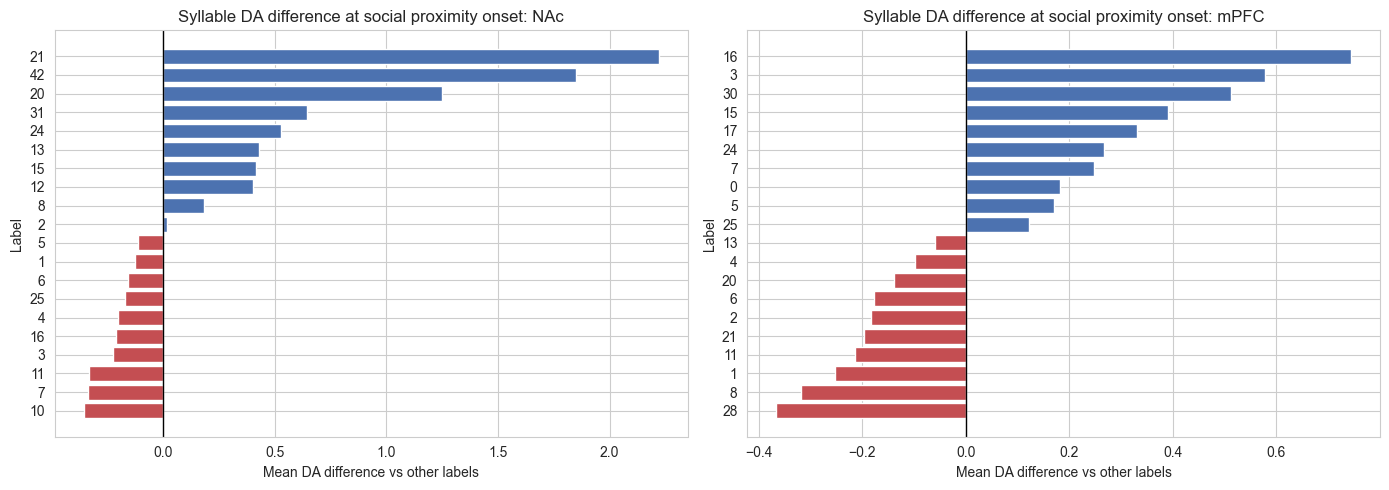

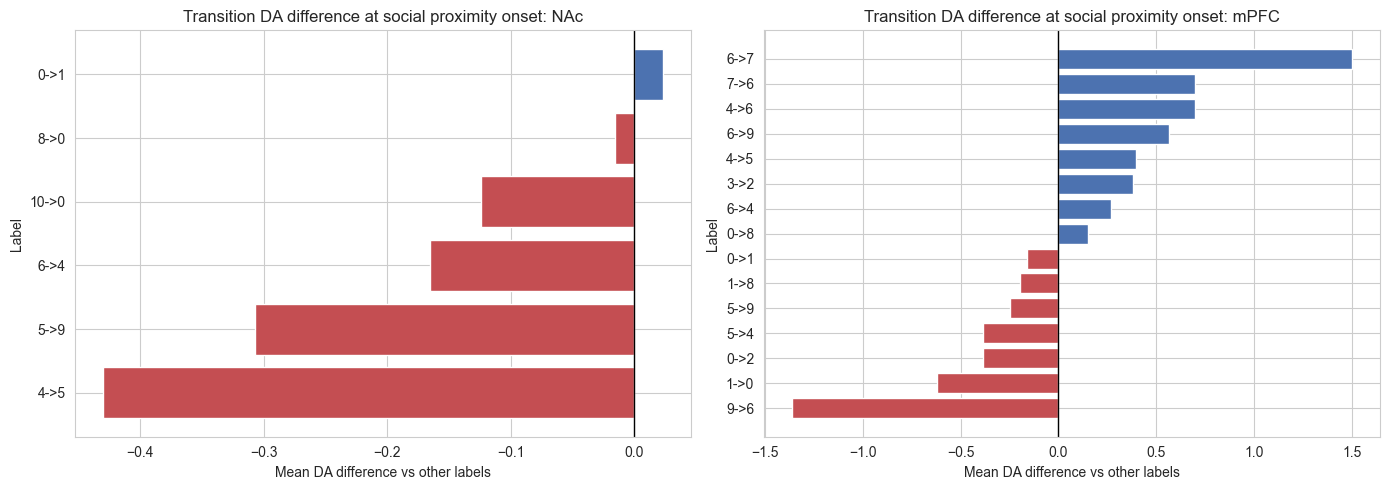

In [127]:
plot_top_delta_bars(
    syllable_da_comparison,
    title_prefix="Syllable DA difference at social proximity onset",
)

plot_top_delta_bars(
    transition_da_comparison,
    title_prefix="Transition DA difference at social proximity onset",
)

c:\Users\alber\anaconda3\envs\keypoint_moseq\lib\site-packages\seaborn\_base.py:948: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_group(pd_key)
c:\Users\alber\anaconda3\envs\keypoint_moseq\lib\site-packages\seaborn\categorical.py:1202: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(aggregator, agg_var)
c:\Users\alber\anaconda3\envs\keypoint_moseq\lib\site-packages\seaborn\_base.py:948: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of

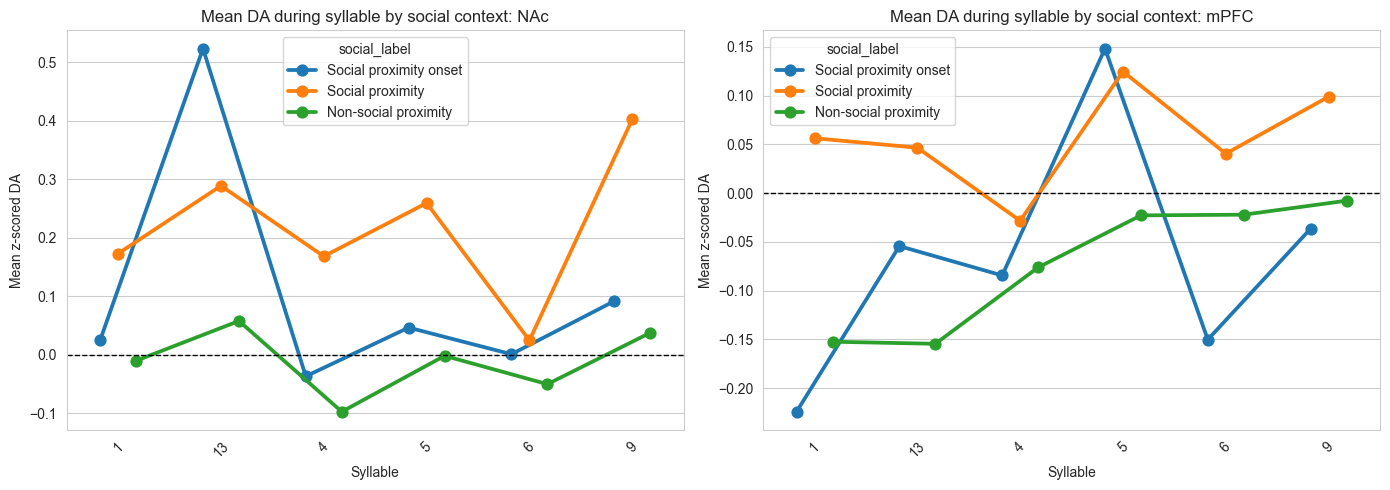

c:\Users\alber\anaconda3\envs\keypoint_moseq\lib\site-packages\seaborn\_base.py:948: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_group(pd_key)
c:\Users\alber\anaconda3\envs\keypoint_moseq\lib\site-packages\seaborn\categorical.py:632: FutureWarning: SeriesGroupBy.grouper is deprecated and will be removed in a future version of pandas.
  positions = grouped.grouper.result_index.to_numpy(dtype=float)
c:\Users\alber\anaconda3\envs\keypoint_moseq\lib\site-packages\seaborn\_base.py:948: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_group(pd_key)
c:\Users\alber\anaconda3\envs\keypoint_moseq\lib\site-packages\seaborn\categorical.p

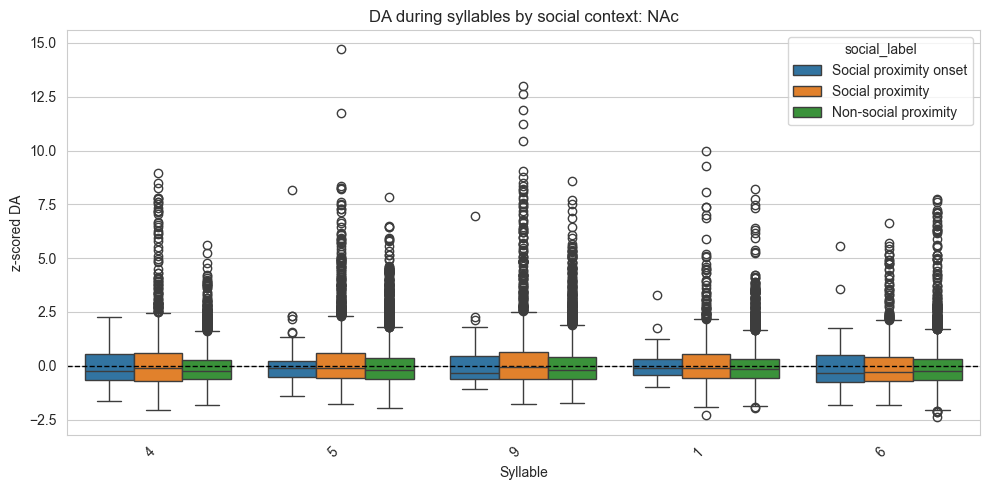

c:\Users\alber\anaconda3\envs\keypoint_moseq\lib\site-packages\seaborn\_base.py:948: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_group(pd_key)
c:\Users\alber\anaconda3\envs\keypoint_moseq\lib\site-packages\seaborn\categorical.py:632: FutureWarning: SeriesGroupBy.grouper is deprecated and will be removed in a future version of pandas.
  positions = grouped.grouper.result_index.to_numpy(dtype=float)
c:\Users\alber\anaconda3\envs\keypoint_moseq\lib\site-packages\seaborn\_base.py:948: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_group(pd_key)
c:\Users\alber\anaconda3\envs\keypoint_moseq\lib\site-packages\seaborn\categorical.p

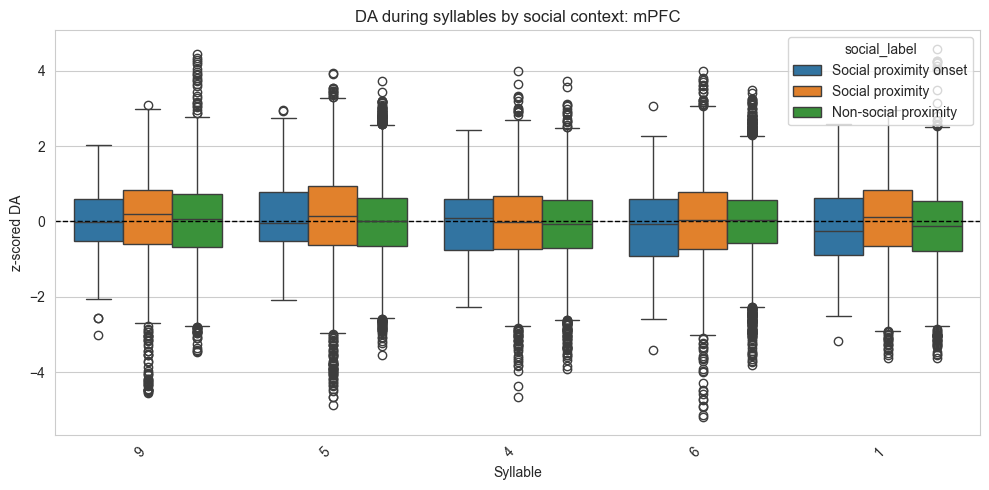

c:\Users\alber\anaconda3\envs\keypoint_moseq\lib\site-packages\seaborn\_base.py:948: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_group(pd_key)
c:\Users\alber\anaconda3\envs\keypoint_moseq\lib\site-packages\seaborn\_base.py:948: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_group(pd_key)
c:\Users\alber\anaconda3\envs\keypoint_moseq\lib\site-packages\seaborn\_base.py:948: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_group(pd_key)
c:\Users\albe

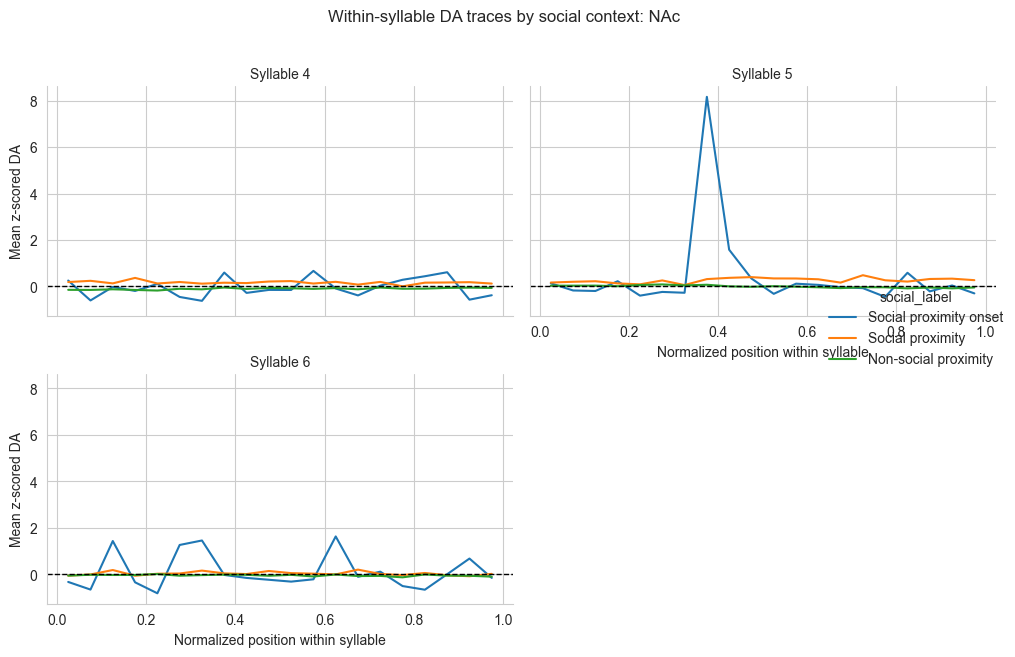

c:\Users\alber\anaconda3\envs\keypoint_moseq\lib\site-packages\seaborn\_base.py:948: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_group(pd_key)
c:\Users\alber\anaconda3\envs\keypoint_moseq\lib\site-packages\seaborn\_base.py:948: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_group(pd_key)
c:\Users\alber\anaconda3\envs\keypoint_moseq\lib\site-packages\seaborn\_base.py:948: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_group(pd_key)
c:\Users\albe

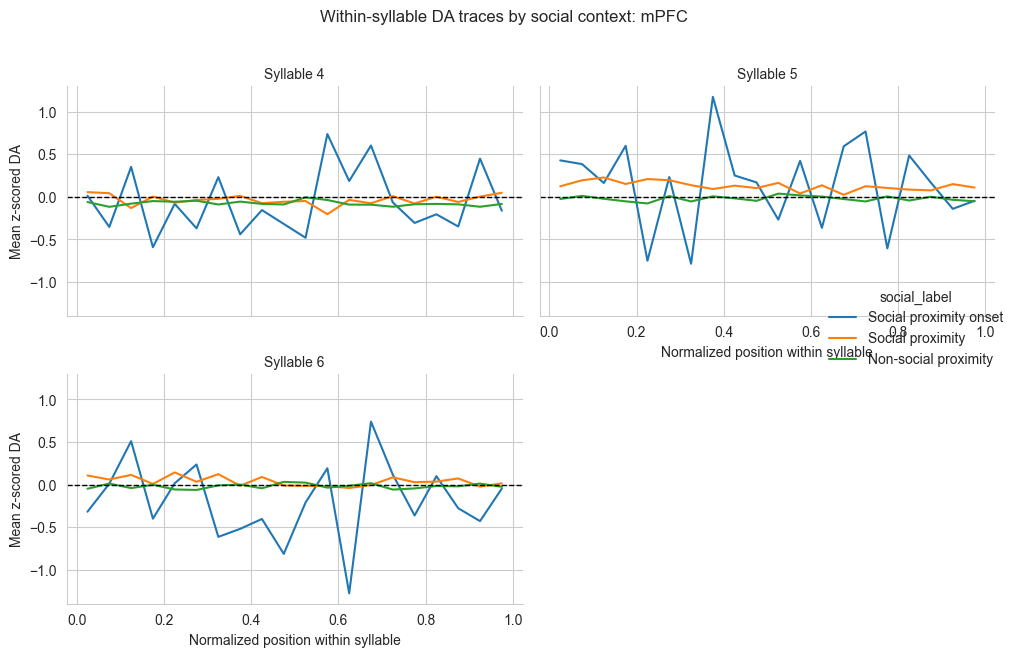

In [128]:
plot_syllable_social_value_points(
    syllable_social_da_summary,
    top_n=8,
)

plot_syllable_social_boxplots(
    da_with_syllables.dropna(subset=["syllable_label", "zscore_DA"]).copy(),
    syllable_social_da_summary,
    top_n=6,
)

plot_syllable_social_traces(
    syllable_social_traces,
    syllable_social_da_summary,
    top_n=4,
)

c:\Users\alber\anaconda3\envs\keypoint_moseq\lib\site-packages\seaborn\categorical.py:632: FutureWarning: SeriesGroupBy.grouper is deprecated and will be removed in a future version of pandas.
  positions = grouped.grouper.result_index.to_numpy(dtype=float)


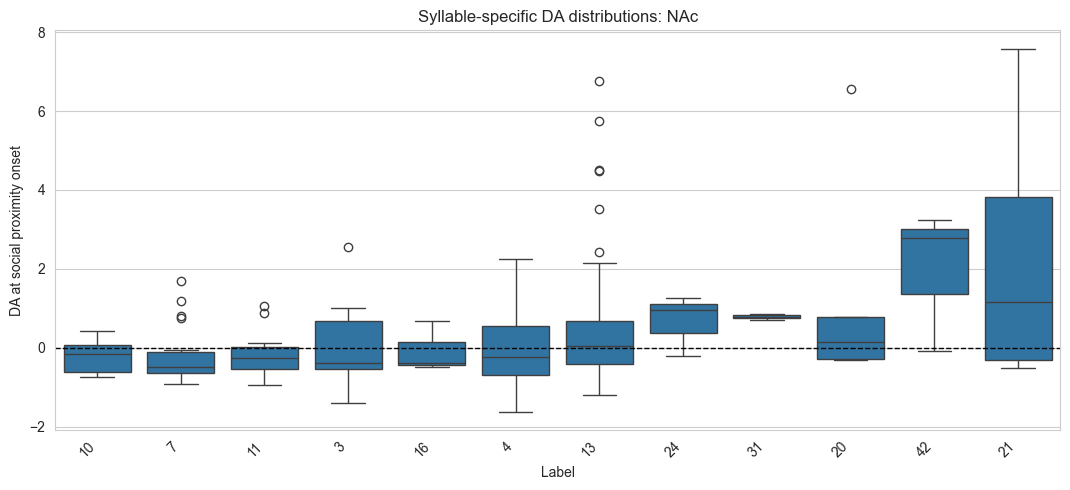

c:\Users\alber\anaconda3\envs\keypoint_moseq\lib\site-packages\seaborn\categorical.py:632: FutureWarning: SeriesGroupBy.grouper is deprecated and will be removed in a future version of pandas.
  positions = grouped.grouper.result_index.to_numpy(dtype=float)


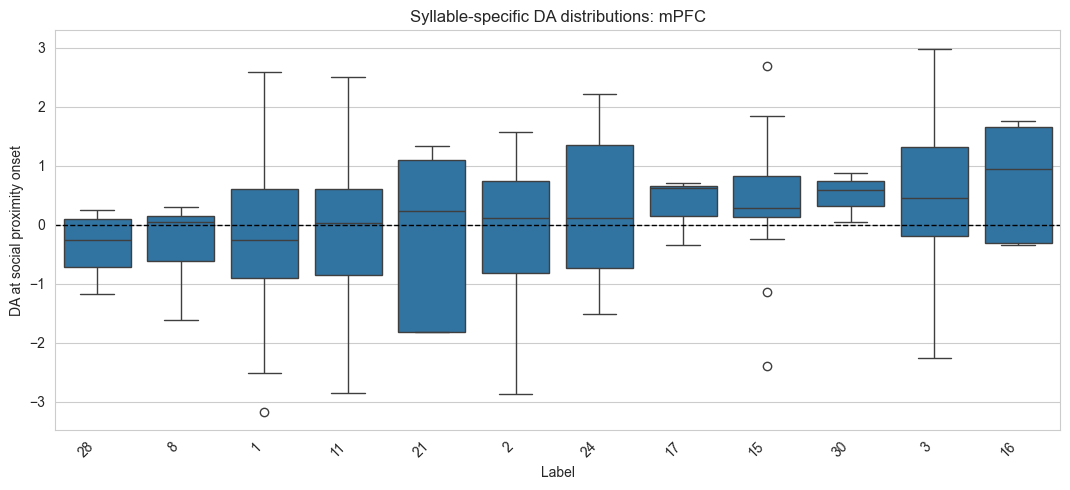

c:\Users\alber\anaconda3\envs\keypoint_moseq\lib\site-packages\seaborn\categorical.py:632: FutureWarning: SeriesGroupBy.grouper is deprecated and will be removed in a future version of pandas.
  positions = grouped.grouper.result_index.to_numpy(dtype=float)


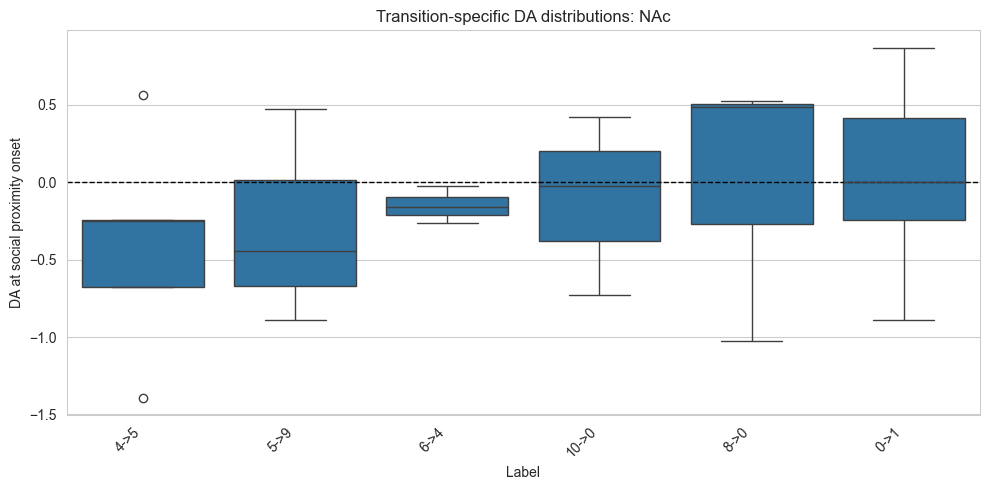

c:\Users\alber\anaconda3\envs\keypoint_moseq\lib\site-packages\seaborn\categorical.py:632: FutureWarning: SeriesGroupBy.grouper is deprecated and will be removed in a future version of pandas.
  positions = grouped.grouper.result_index.to_numpy(dtype=float)


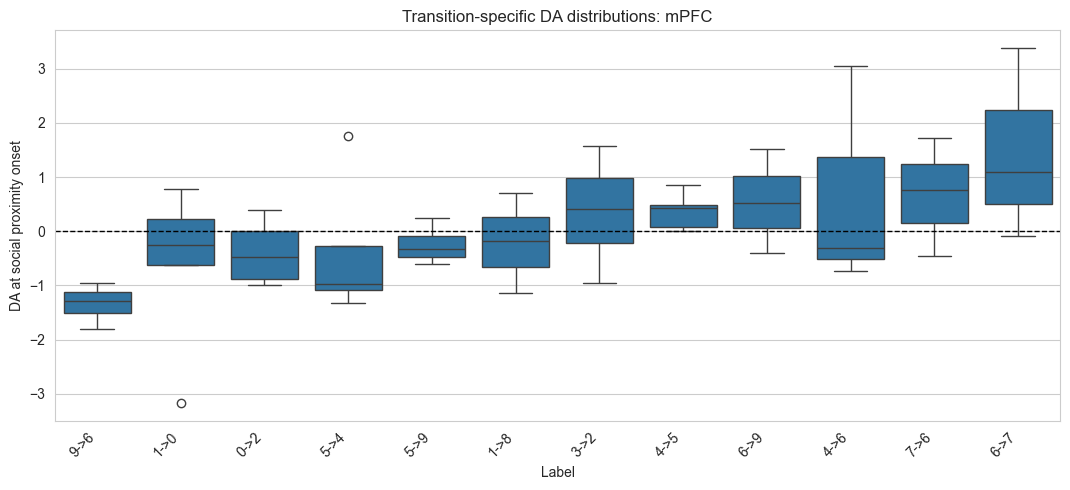

In [129]:
plot_top_boxplots(
    social_onsets.dropna(subset=["syllable_label", "zscore_DA"]).copy(),
    syllable_da_comparison,
    label_col="syllable_label",
    title_prefix="Syllable-specific DA distributions",
)

plot_top_boxplots(
    social_onsets[social_onsets["matched_transition"]].dropna(subset=["transition_label", "zscore_DA"]).copy(),
    transition_da_comparison,
    label_col="transition_label",
    title_prefix="Transition-specific DA distributions",
)

## Quick follow-up views

In [130]:
top_syllables = social_onsets["syllable_label"].value_counts(dropna=True).head(15).rename_axis("syllable_label").reset_index(name="n_onsets")
top_transitions = social_onsets.loc[
    social_onsets["matched_transition"], "transition_label"
].value_counts(dropna=True).head(15).rename_axis("transition_label").reset_index(name="n_onsets")

display(top_syllables)
display(top_transitions)

,syllable_label,n_onsets
0,5,208
1,6,171
2,4,159
3,1,133
4,9,130
5,13,105
6,7,60
7,2,57
8,3,55
9,0,43


,transition_label,n_onsets
0,0->1,14
1,4->5,10
2,0->8,7
3,1->0,7
4,5->9,7
5,6->4,6
6,9->6,6
7,5->4,6
8,3->2,6
9,0->2,5


## Interpretation notes

- `syllable_enrichment` asks whether some syllables are active at social proximity onset more often than expected from overall occupancy time.
- `transition_enrichment` asks whether some transitions occur near social proximity onset more often than expected from overall transition frequency.
- `syllable_da_comparison` asks whether DA at social proximity onset is higher or lower for a given active syllable than for the other social-proximity syllables in the same region.
- `transition_da_comparison` asks whether DA at social proximity onset is higher or lower for a given matched transition than for the other social-proximity transitions in the same region.
- A natural next step is to tighten the temporal question further by testing transitions that occur just before onset versus just after onset, or by building a transition-conditioned logistic model for proximity entry.